# Reflection-Mode Optical Diffraction Tomography (rMS-FPT)

This notebook demonstrates 3D refractive index reconstruction from reflection-mode Fourier ptychographic tomography measurements.

**Reference**: Zhu et al., "Reflection-mode multi-slice Fourier ptychographic tomography", arXiv:2503.12246 (2025)

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import json

from src.visualization import (
    plot_ri_slices,
    plot_comparison,
    plot_loss_history,
    plot_measurements,
    compute_metrics,
    print_metrics_table,
)

%matplotlib inline

## 1. Load Precomputed Results

We load the reference outputs generated by `main.py` for quick visualization.

In [2]:
ref_dir = '../evaluation/reference_outputs'

ground_truth = np.load(f'{ref_dir}/ground_truth.npy')
measurements = np.load(f'{ref_dir}/measurements.npy')
reconstruction = np.load(f'{ref_dir}/reconstruction.npy')
loss_history = np.load(f'{ref_dir}/loss_history.npy')

with open(f'{ref_dir}/metrics.json', 'r') as f:
    metrics = json.load(f)

print(f"Ground truth shape: {ground_truth.shape}")
print(f"Measurements shape: {measurements.shape}")
print(f"Reconstruction shape: {reconstruction.shape}")
print(f"\nΔn range (GT): [{ground_truth.min():.4f}, {ground_truth.max():.4f}]")
print(f"Δn range (recon): [{reconstruction.min():.4f}, {reconstruction.max():.4f}]")

Ground truth shape: (4, 128, 128)
Measurements shape: (16, 128, 128)
Reconstruction shape: (4, 128, 128)

Δn range (GT): [-0.0700, 0.0000]
Δn range (recon): [-0.0950, 0.0620]


## 2. Visualize Ground Truth Phantom

4-layer synthetic phantom with USAF-like patterns (Δn = -0.07).

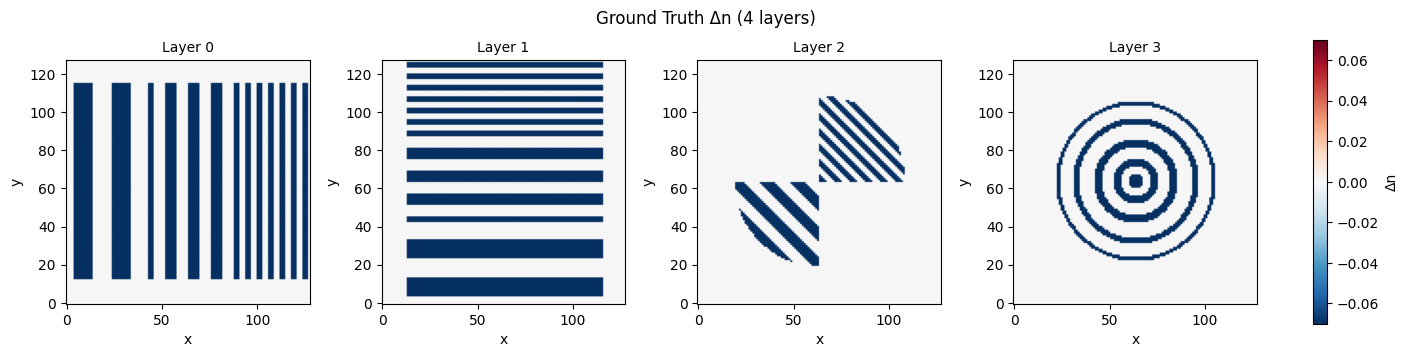

In [3]:
fig = plot_ri_slices(ground_truth, title="Ground Truth Δn (4 layers)")
plt.show()

## 3. Visualize Measurements

Intensity images from 16 illumination angles (NA=0.28, λ=632nm).

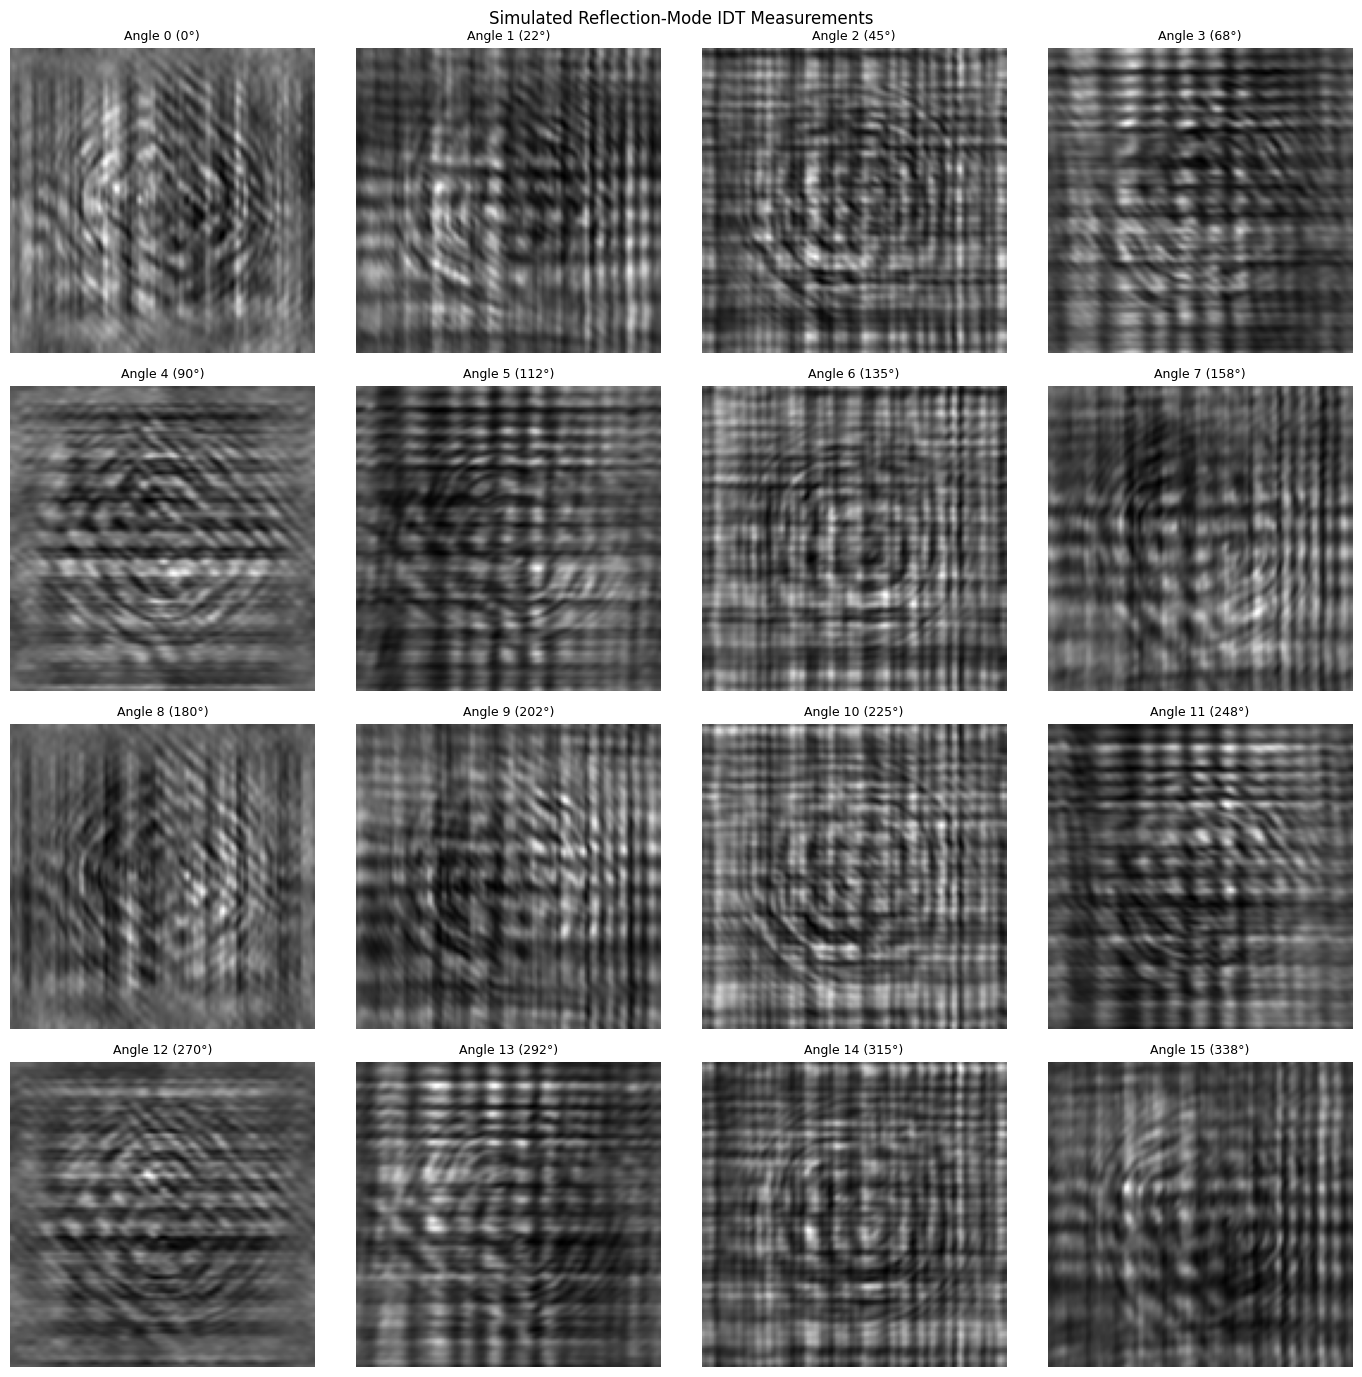

In [4]:
fig = plot_measurements(measurements)
plt.show()

## 4. Reconstruction Results

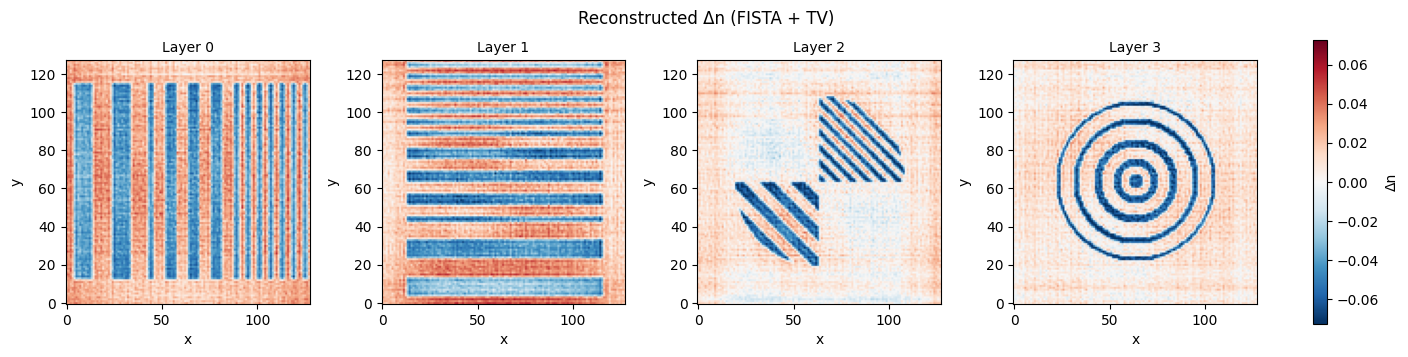

In [5]:
fig = plot_ri_slices(reconstruction, title="Reconstructed Δn (FISTA + TV)")
plt.show()

## 5. Comparison

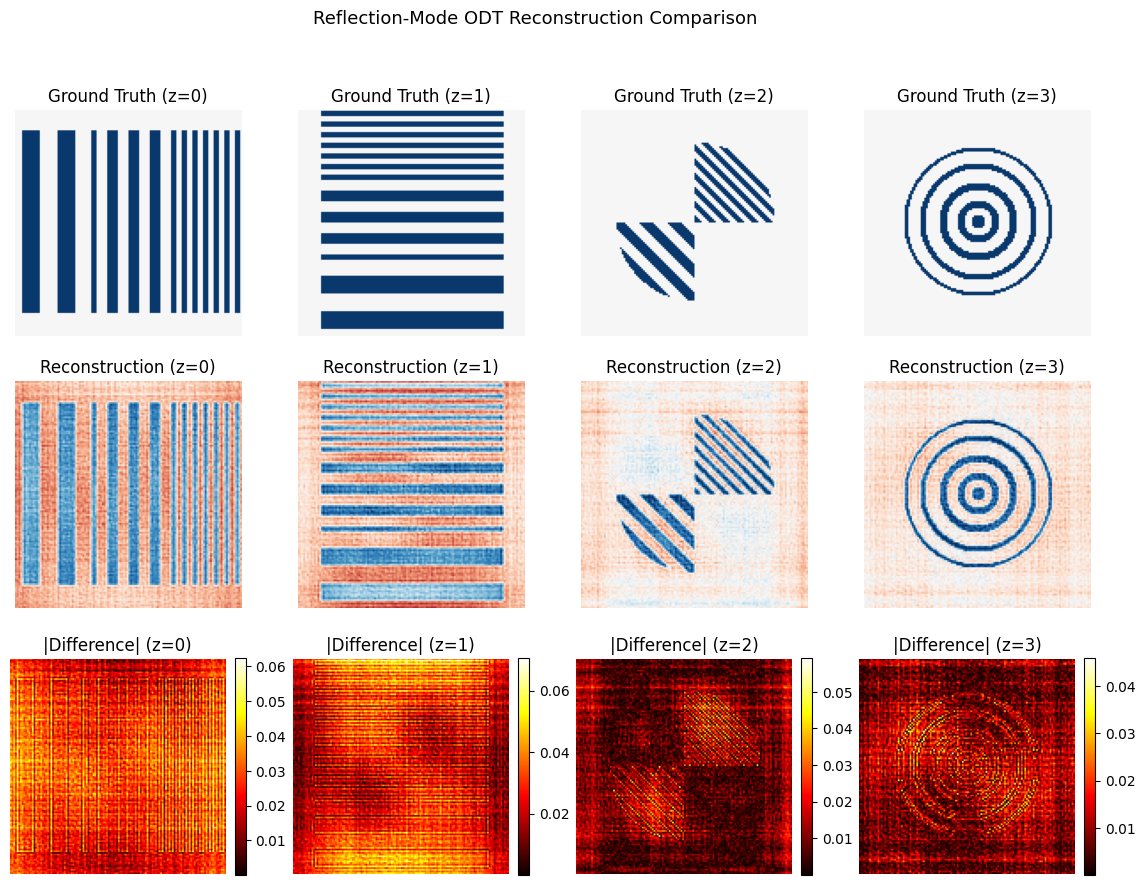

In [6]:
fig = plot_comparison(ground_truth, reconstruction)
plt.show()

## 6. Loss Convergence

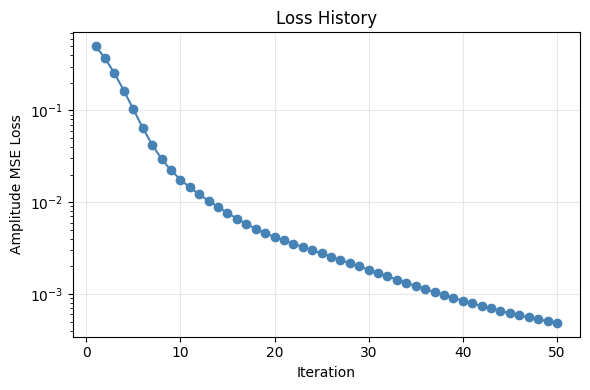

In [7]:
fig = plot_loss_history(loss_history.tolist())
plt.show()

## 7. Quantitative Metrics

In [8]:
# Recompute metrics to verify
recomputed = compute_metrics(reconstruction, ground_truth)
print("Reconstruction quality metrics:")
print_metrics_table(recomputed)

print(f"\nStored metrics: {metrics}")

Reconstruction quality metrics:
  Metric            Value
  ──────────── ──────────
  NRMSE            0.6499
  NCC              0.8768
  SSIM             0.1526

Stored metrics: {'nrmse': 0.6498747172575662, 'ncc': 0.8768132619129313, 'ssim': 0.15256773147171998}


## 8. Run Full Pipeline (Optional)

Uncomment the cell below to run the full reconstruction pipeline from scratch. This requires a GPU and takes several minutes.

In [9]:
# import torch
# from src.preprocessing import prepare_data
# from src.physics_model import ReflectionBPMConfig, ReflectionBPMForwardModel
# from src.solvers import ReflectionBPMReconstructor
#
# device = "cuda" if torch.cuda.is_available() else "cpu"
#
# # Step 1: Load data
# phantom_dn, metadata = prepare_data("../data")
# config = ReflectionBPMConfig.from_metadata(metadata)
#
# # Step 2: Build forward model
# model = ReflectionBPMForwardModel(config, device=device)
#
# # Step 3: Simulate measurements
# dn_tensor = torch.tensor(phantom_dn, dtype=torch.float64, device=device)
# with torch.no_grad():
#     meas = model.forward(dn_tensor)
#
# # Step 4: Reconstruct
# reconstructor = ReflectionBPMReconstructor(
#     n_iter=50, lr=5.0, tv_weight=8e-7, positivity=False, device=device
# )
# meas_amp = torch.sqrt(meas)
# dn_recon, loss_hist = reconstructor.reconstruct(meas_amp, model)
#
# # Step 5: Evaluate
# metrics_new = compute_metrics(dn_recon, phantom_dn)
# print_metrics_table(metrics_new)